<a href="https://colab.research.google.com/github/Amri1003/Machine_Learning_Projects/blob/main/EmployeeTurnOver.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [66]:
import  pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import seaborn as sns
from sklearn.cluster import KMeans

print('Imported')






Imported


In [67]:
import warnings
warnings.filterwarnings('ignore')

In [68]:
# load the dataset

data=pd.read_csv('/content/HR_comma_sep.csv')

data






,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [69]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


1.	Perform data quality checks by checking for missing values, if any

In [70]:
data.isnull().sum().any()  # Output comes np.False it means no missing values.

np.False_

2.1.	Draw a heatmap of the correlation matrix between all numerical features or columns in the data.

In [71]:
# First take all numerical values
num_var=data.select_dtypes(include=['int64','float64'])
num_var

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
0,0.38,0.53,2,157,3,0,1,0
1,0.80,0.86,5,262,6,0,1,0
2,0.11,0.88,7,272,4,0,1,0
3,0.72,0.87,5,223,5,0,1,0
4,0.37,0.52,2,159,3,0,1,0
...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0
14995,0.37,0.48,2,160,3,0,1,0
14996,0.37,0.53,2,143,3,0,1,0
14997,0.11,0.96,6,280,4,0,1,0


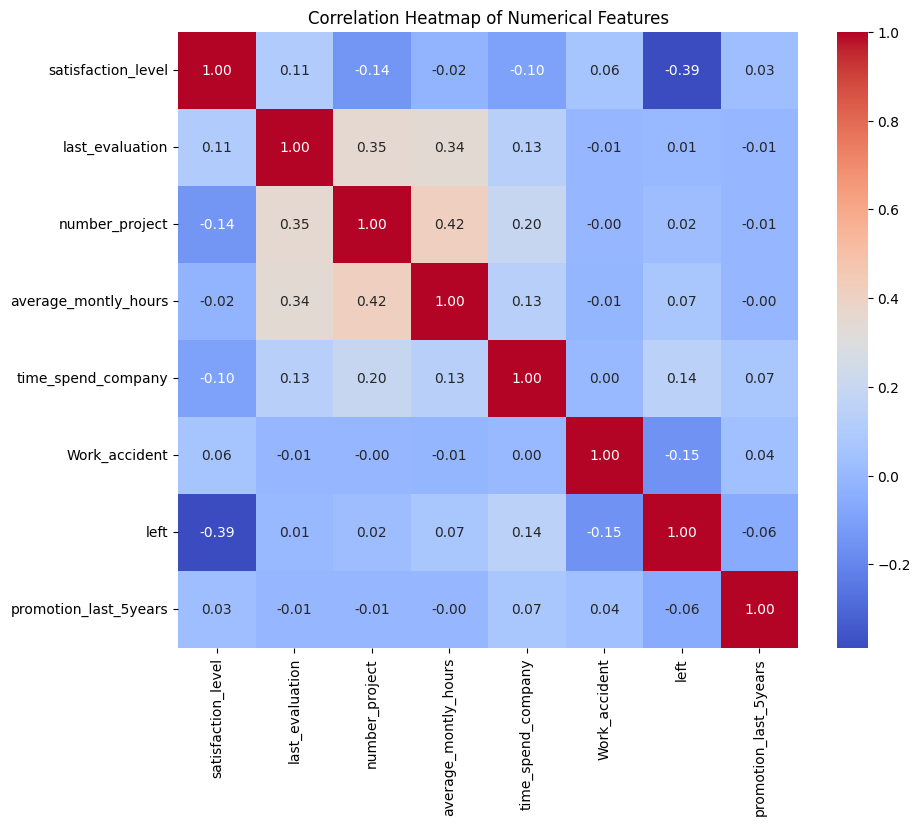

In [72]:
# Compute correlation matrix
corr_matrix = num_var.corr()

# Plot heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix,
            annot=True,      # shows correlation values
            cmap='coolwarm', # color style
            fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

2.2. Draw the distribution plot of:

■ Employee Satisfaction (use column satisfaction_level)

■ Employee Evaluation (use column last_evaluation)

■ Employee Average Monthly Hours (use column average_montly_hours

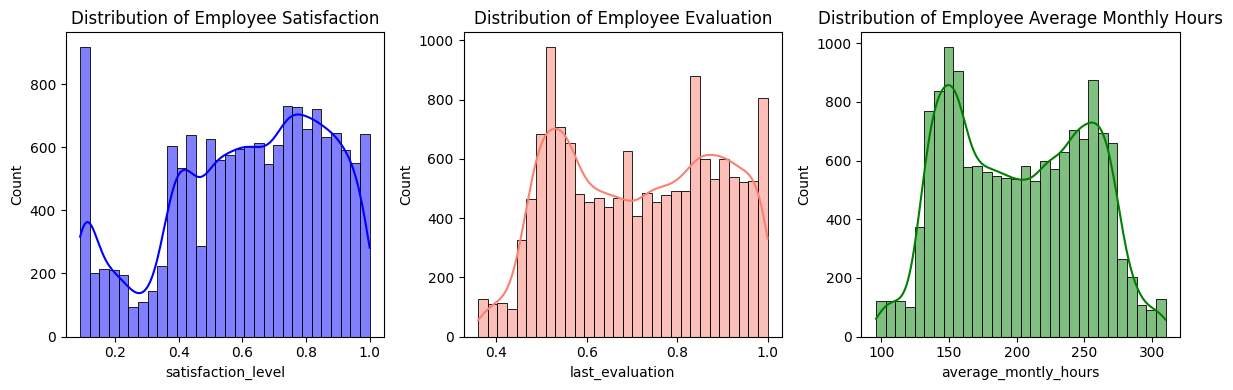

In [73]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
sns.histplot(data['satisfaction_level'], kde=True, bins=30,color='b')
plt.title('Distribution of Employee Satisfaction')

plt.subplot(1,3,2)
sns.histplot(data['last_evaluation'], kde=True, bins=30,color='salmon')
plt.title('Distribution of Employee Evaluation')

plt.subplot(1,3,3)
sns.histplot(data['average_montly_hours'], kde=True, bins=30,color='green')
plt.title('Distribution of Employee Average Monthly Hours')
plt.tight_layout()
plt.show()

In [74]:
#ical_data = data.select_dtypes(include=['number'])






2.3.	Draw the bar plot of the employee project count of both employees who left and stayed in the organization (use column number_project and hue column left), and give your inferences from the plot.

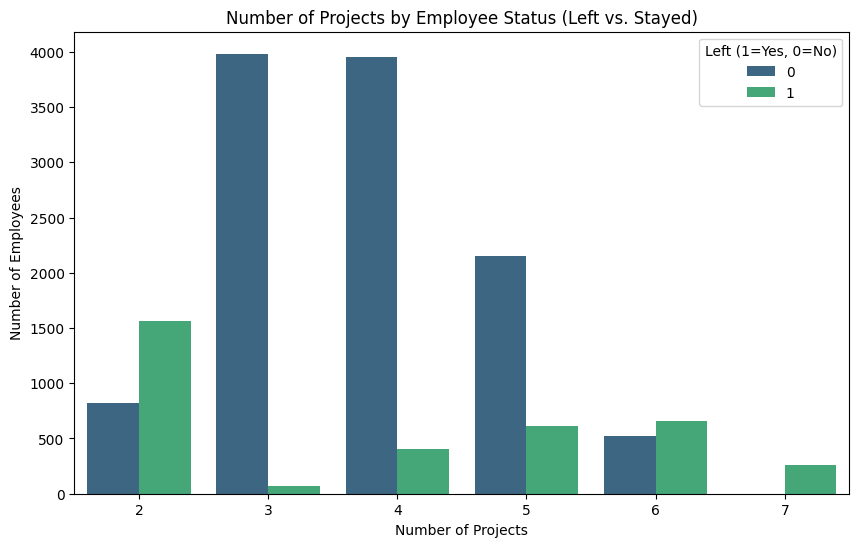

In [75]:
plt.figure(figsize=(10, 6))
sns.countplot(x='number_project', hue='left', data=data, palette='viridis')
plt.title('Number of Projects by Employee Status (Left vs. Stayed)')
plt.xlabel('Number of Projects')
plt.ylabel('Number of Employees')
plt.legend(title='Left (1=Yes, 0=No)')
plt.show()

### Inferences from the Project Count Bar Plot:

*   **Employees with 2 projects:** A significant number of employees who left had only 2 projects. This might indicate that these employees felt underutilized or bored.
*   **Employees with 3-5 projects:** Most employees who stayed in the company had 3, 4, or 5 projects. This suggests an optimal workload or engagement level.
*   **Employees with 6-7 projects:** A higher proportion of employees with 6 or 7 projects left the company compared to those who stayed. This could indicate burnout or excessive workload leading to dissatisfaction and departure.

Overall, the plot suggests that both under-utilization (2 projects) and over-utilization (6-7 projects) in terms of project count might be contributing factors to employees leaving the company.

## Create count plot of salary (hue=left), dept-sales vs left(hue)

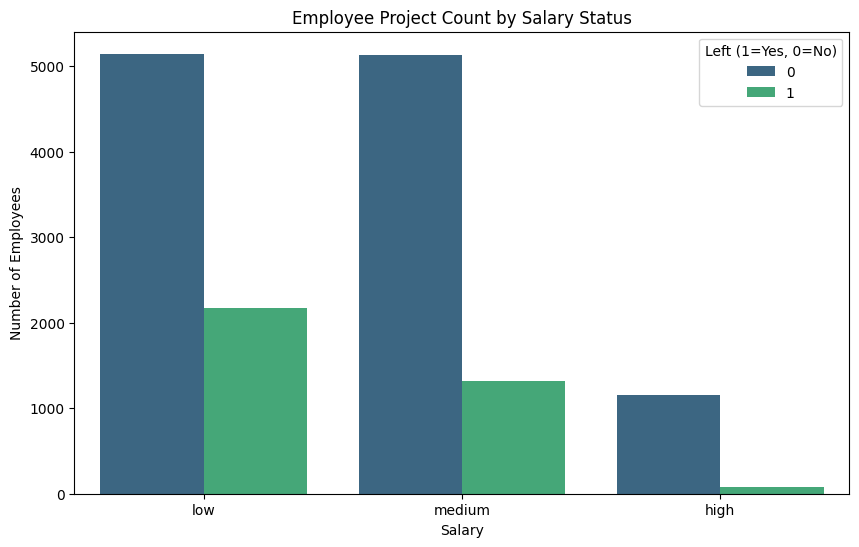

In [76]:
plt.figure(figsize=(10, 6))
sns.countplot(x='salary', hue='left', data=data, palette='viridis')
plt.title('Employee Project Count by Salary Status')
plt.xlabel('Salary')
plt.ylabel('Number of Employees')
plt.legend(title='Left (1=Yes, 0=No)')
plt.show()

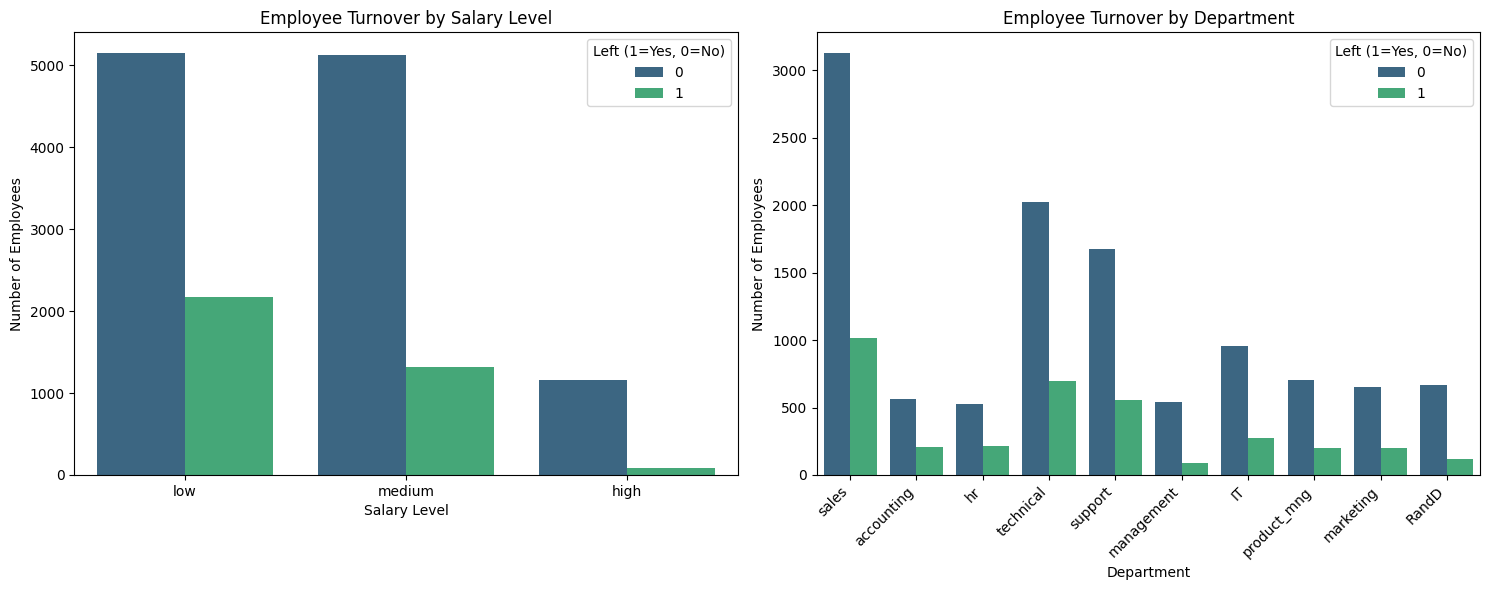

In [77]:
# Few more charts for analysis
plt.figure(figsize=(15, 6))
plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.countplot(data=data, x='salary', hue='left', palette='viridis')
plt.title('Employee Turnover by Salary Level')
plt.xlabel('Salary Level')
plt.ylabel('Number of Employees')
plt.legend(title='Left (1=Yes, 0=No)')
plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.countplot(data=data, x='sales', hue='left', palette='viridis')
plt.title('Employee Turnover by Department')
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Left (1=Yes, 0=No)')
plt.tight_layout()
plt.show()

In [78]:
# Count of all the employees who left the company, Left=1
data['left'].value_counts()

,count
left,
0,11428
1,3571


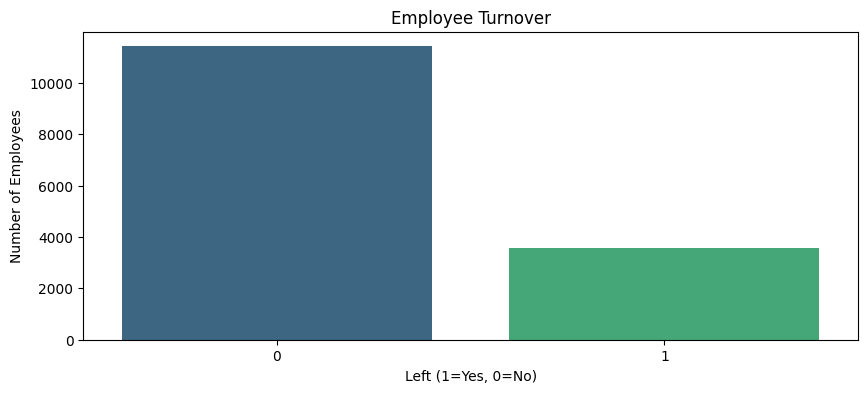

In [79]:

# create chart
plt.figure(figsize=(10,4))
sns.countplot(x='left', data=data, palette='viridis')
plt.title('Employee Turnover')
plt.xlabel('Left (1=Yes, 0=No)')
plt.ylabel('Number of Employees')
plt.show()

3.
Perform clustering of employees who left based on their satisfaction and evaluation.

3.1.	Choose columns satisfaction_level, last_evaluation, and left.

3.2.	Do K-means clustering of employees who left the company into 3 clusters?

3.3.	Based on the satisfaction and evaluation factors, give your thoughts on the employee clusters.


In [80]:
left_employees = data[data['left'] == 1]
clustering_data = left_employees[['satisfaction_level', 'last_evaluation']]
print("Shape of the data for clustering:", clustering_data.shape)
print(clustering_data.head())

Shape of the data for clustering: (3571, 2)
   satisfaction_level  last_evaluation
0                0.38             0.53
1                0.80             0.86
2                0.11             0.88
3                0.72             0.87
4                0.37             0.52


In [81]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(clustering_data)

KMeans(n_clusters=3, random_state=42)

In [82]:
kmeans.labels_

array([0, 1, 2, ..., 0, 2, 0], dtype=int32)

In [83]:
clustering_data['cluster']=kmeans.labels_
clustering_data

,satisfaction_level,last_evaluation,cluster
0,0.38,0.53,0
1,0.80,0.86,1
2,0.11,0.88,2
3,0.72,0.87,1
4,0.37,0.52,0
...,...,...,...
14994,0.40,0.57,0
14995,0.37,0.48,0
14996,0.37,0.53,0
14997,0.11,0.96,2


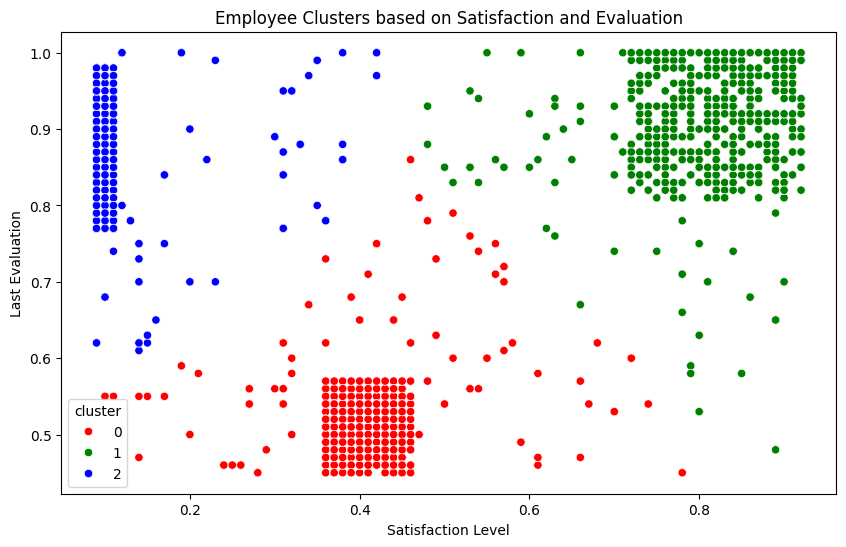

In [84]:
# visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='satisfaction_level', y='last_evaluation', hue='cluster', data=clustering_data
                ,palette=['red', 'green', 'blue'])
plt.title('Employee Clusters based on Satisfaction and Evaluation')
plt.xlabel('Satisfaction Level')
plt.ylabel('Last Evaluation')
plt.show()

Inference based on the above values and chart


**Cluster 0** (Low Satisfaction, Moderate Evaluation): These employees likely left due to general unhappiness or disengagement, might have found better oppurtinities.

**Cluster 1** (High Satisfaction, High Evaluation):  These employees were both highly satisfied and highly evaluated. Due to better options available or any other personal reason they might have left.

**Cluster 2**  (Very Low Satisfaction, High Evaluation): This represents a critical group. These are high-performing employees (high evaluation) who are extremely dissatisfied. This could be a clear sign of burnout, excessive workload, lack of work-life balance, or feeling unappreciated despite their significant contributions. This group is particularly concerning as they represent a loss of valuable talent.

4.	Handle the left Class Imbalance using the SMOTE technique.

4.1.	Pre-process the data by converting categorical columns to numerical columns by:

■	Separating categorical variables and numeric variables

■	Applying get_dummies() to the categorical variables

■	Combining categorical variables and numeric variables

4.2.	Do the stratified split of the dataset to train and test in the ratio 80:20 with random_state=123.

4.3.	Upsample the train dataset using the SMOTE technique from the imblearn module.


In [85]:
# segregation of categorical and numeric variables
categorical_data = data.select_dtypes(include=['object'])
numerical_data = data.select_dtypes(include=['int64', 'float64'])

In [86]:
categorical_data.shape

(14999, 2)

In [87]:
numerical_data.shape

(14999, 8)

In [88]:
categorical_cols_encoded = pd.get_dummies(categorical_data).astype(int)

In [89]:
categorical_cols_encoded

,sales_IT,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
0,0,0,0,0,0,0,0,1,0,0,0,1,0
1,0,0,0,0,0,0,0,1,0,0,0,0,1
2,0,0,0,0,0,0,0,1,0,0,0,0,1
3,0,0,0,0,0,0,0,1,0,0,0,1,0
4,0,0,0,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0,0,0,0,0,0,0,0,1,0,0,1,0
14995,0,0,0,0,0,0,0,0,1,0,0,1,0
14996,0,0,0,0,0,0,0,0,1,0,0,1,0
14997,0,0,0,0,0,0,0,0,1,0,0,1,0


In [90]:
# combine encoded data with other numerical data
df_combined=pd.concat([numerical_data,categorical_cols_encoded],axis=1)
df_combined

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_IT,sales_RandD,...,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_high,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,0.80,0.86,5,262,6,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.11,0.88,7,272,4,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,0.72,0.87,5,223,5,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,0.37,0.52,2,159,3,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
14995,0.37,0.48,2,160,3,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
14996,0.37,0.53,2,143,3,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0
14997,0.11,0.96,6,280,4,0,1,0,0,0,...,0,0,0,0,0,1,0,0,1,0


## create indep & dep var, splitting

In [91]:
from sklearn.model_selection import train_test_split

X = df_combined.drop('left', axis=1)
y = df_combined['left']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)

In [93]:
# To apply SMOTE, need to install a library
!pip install imblearn

In [94]:
y_train.value_counts()

,count
left,
0,9142
1,2857


In [95]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=123)
X_train_upscaled, y_train_upscaled = smote.fit_resample(X_train, y_train)

In [96]:
y_train_upscaled.value_counts()

,count
left,
0,9142
1,9142


In [97]:
X_train_upscaled.shape

(18284, 20)

5.	Perform 5-fold cross-validation model training and evaluate performance.

5.1.	Train a logistic regression model, apply a 5-fold CV, and plot the classification report.

5.2.	Train a Random Forest Classifier model, apply the 5-fold CV, and plot the classification report.

5.3.	Train a Gradient Boosting Classifier model, apply the 5-fold CV, and plot the classification report.

6.	Identify the best model and justify the evaluation metrics used.
6.1.	Find the ROC/AUC for each model and plot the ROC curve.

6.2.	Find the confusion matrix for each of the models.

6.3.	Explain which metric needs to be used from the confusion matrix: Recall or Precision?


In [98]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier


## Apply Log reg, prediction, calculate all metrics, build ROC graph, cross val score

In [99]:
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')

In [100]:
# print cross validation score
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(log_reg_model, X_train_upscaled, y_train_upscaled, cv=5).mean()
print("Cross Validation Score:", cv_scores)


Cross Validation Score: 0.8081399001585041


In [101]:
# fit and predict
log_reg_model.fit(X_train_upscaled, y_train_upscaled)
y_pred = log_reg_model.predict(X_test)

In [102]:
# print all metrices
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.7846666666666666
Precision: 0.5349794238683128
Recall: 0.7282913165266106
F1 Score: 0.6168446026097272


In [103]:
# print confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)

In [104]:
cm

array([[1834,  452],
       [ 194,  520]])

In [105]:
# print classification report
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.80      0.85      2286
           1       0.53      0.73      0.62       714

    accuracy                           0.78      3000
   macro avg       0.72      0.77      0.73      3000
weighted avg       0.82      0.78      0.79      3000



In [106]:
# print roc auc score
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_pred)
print("ROC AUC Score:", roc_auc)


ROC AUC Score: 0.7652830160935765


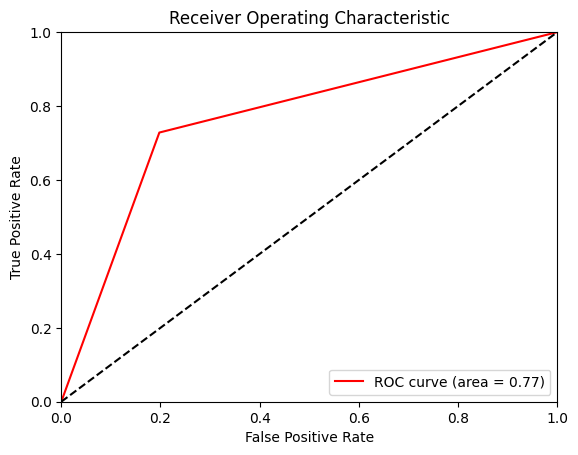

In [107]:
# print roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc
         ,color='red')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()


##Apply Random Forest

In [108]:
rf = RandomForestClassifier(max_depth=5,random_state=42)
cv_scores = cross_val_score(rf, X_train_upscaled, y_train_upscaled, cv=5).mean()
print("Mean CV Score:", cv_scores.mean())

Mean CV Score: 0.9520891560742895


In [109]:
rf.fit(X_train_upscaled, y_train_upscaled)
y_pred = rf.predict(X_test)

In [110]:
# print all metrices
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.962
Precision: 0.923728813559322
Recall: 0.9159663865546218
F1 Score: 0.919831223628692


In [111]:
# print confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[2232,   54],
       [  60,  654]])

In [112]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.98      0.98      2286
           1       0.92      0.92      0.92       714

    accuracy                           0.96      3000
   macro avg       0.95      0.95      0.95      3000
weighted avg       0.96      0.96      0.96      3000



In [113]:
# print roc auc score
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_pred)
print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.9461721696552636


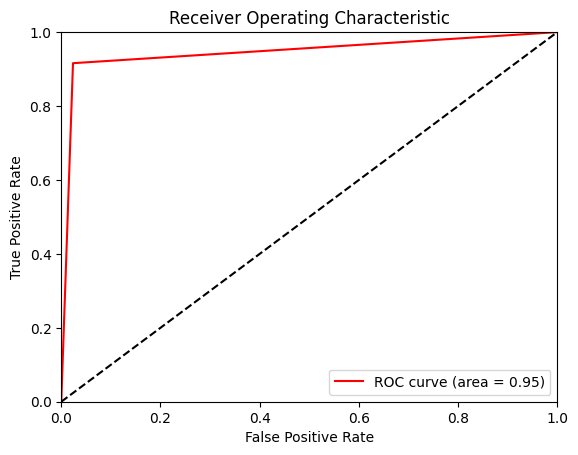

In [114]:
# print roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc
         ,color='red')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

## Apply GradientBoosting Classifier

In [115]:
gb=GradientBoostingClassifier(random_state=42,max_depth=2)
cv_scores = cross_val_score(gb, X_train_upscaled, y_train_upscaled, cv=5).mean()
print("Mean CV Score:", cv_scores.mean())

Mean CV Score: 0.9468385620574791


In [116]:
# train and predict
gb.fit(X_train_upscaled, y_train_upscaled)
y_pred = gb.predict(X_test)

In [117]:
# print all metrices
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.949
Precision: 0.8619354838709677
Recall: 0.9355742296918768
F1 Score: 0.8972464741437206


In [118]:
# print confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[2179,  107],
       [  46,  668]])

In [119]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.97      2286
           1       0.86      0.94      0.90       714

    accuracy                           0.95      3000
   macro avg       0.92      0.94      0.93      3000
weighted avg       0.95      0.95      0.95      3000



In [120]:
# print roc auc score
from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(y_test, y_pred)
print("ROC AUC Score:", roc_auc)

ROC AUC Score: 0.9443837902615114


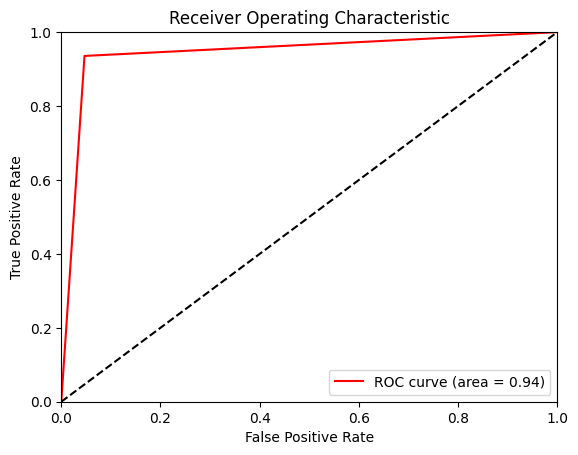

In [121]:
# print roc curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc
         ,color='red')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

7.	Suggest various retention strategies for targeted employees.

7.1.	Using the best model, predict the probability of employee turnover in the test data.

7.2.	Based on the probability score range below, categorize the employees into four zones and suggest your thoughts on the
retention strategies for each zone.

■	Safe Zone (Green) (Score < 20%)

■	Low-Risk Zone (Yellow) (20% < Score < 60%)

■	Medium-Risk Zone (Orange) (60% < Score < 90%)

■	High-Risk Zone (Red) (Score > 90%).


In [122]:
#print feature importance using random forest model with feature names also
importances = rf.feature_importances_
# sort imporatnces
indices = np.argsort(importances)[::-1]
# print feature importance
print("Feature importances:")
for f in range(X_train_upscaled.shape[1]):
    print(f"{X_train_upscaled.columns[indices[f]]}: {importances[indices[f]]}")


Feature importances:
satisfaction_level: 0.33292837807523684
time_spend_company: 0.20769571538984477
number_project: 0.1658643083055097
average_montly_hours: 0.12954594115977483
last_evaluation: 0.10046543562378212
Work_accident: 0.03497226179559362
salary_high: 0.014441012019156454
salary_low: 0.004095150780555877
salary_medium: 0.0019695701292892728
sales_RandD: 0.0018553252542049606
sales_management: 0.0017133698241124033
promotion_last_5years: 0.0016194506395414896
sales_IT: 0.001021844803117897
sales_product_mng: 0.00038722165767083786
sales_sales: 0.0003242355589094707
sales_marketing: 0.0002881893200271448
sales_accounting: 0.00026569652625370153
sales_technical: 0.00018674096669291324
sales_support: 0.00018172132215044435
sales_hr: 0.00017843084857529178


In [123]:
# predict the prob on test data using random forest model
y_pred_prob = rf.predict_proba(X_test)
y_pred_prob[:,1]

array([0.07837457, 0.54586587, 0.21061708, ..., 0.19475945, 0.11186948,
       0.66736739])

In [124]:
#. Based on the probability score range below, categorize the employees into four zones and suggest your thoughts on the retention strategies for each zone.

#■ Safe Zone (Green) (Score < 20%)

#■ Low-Risk Zone (Yellow) (20% < Score < 60%)

#■ Medium-Risk Zone (Orange) (60% < Score < 90%)

#■ High-Risk Zone (Red) (Score > 90%).

zone=[]
prob=[]

for i in y_pred_prob[:,1]:
    if i<0.2:
        zone.append('Safe Zone')
        prob.append(i)
    elif i>=0.2 and i<0.6:
        zone.append('Low-Risk Zone')
        prob.append(i)
    elif i>=0.6 and i<0.9:
        zone.append('Medium-Risk Zone')
        prob.append(i)
    else:
        zone.append('High-Risk Zone')
        prob.append(i)


In [125]:
zone

['Safe Zone',
 'Low-Risk Zone',
 'Low-Risk Zone',
 'Safe Zone',
 'Safe Zone',
 'Safe Zone',
 'Safe Zone',
 'Safe Zone',
 'Safe Zone',
 'Safe Zone',
 'High-Risk Zone',
 'Low-Risk Zone',
 'High-Risk Zone',
 'Safe Zone',
 'Safe Zone',
 'Medium-Risk Zone',
 'Safe Zone',
 'Safe Zone',
 'Safe Zone',
 'High-Risk Zone',
 'Low-Risk Zone',
 'High-Risk Zone',
 'Safe Zone',
 'Low-Risk Zone',
 'Safe Zone',
 'Safe Zone',
 'Medium-Risk Zone',
 'Low-Risk Zone',
 'Safe Zone',
 'Low-Risk Zone',
 'Safe Zone',
 'Medium-Risk Zone',
 'High-Risk Zone',
 'Low-Risk Zone',
 'Safe Zone',
 'Medium-Risk Zone',
 'High-Risk Zone',
 'Safe Zone',
 'Safe Zone',
 'Safe Zone',
 'Safe Zone',
 'Safe Zone',
 'Low-Risk Zone',
 'Safe Zone',
 'Safe Zone',
 'High-Risk Zone',
 'Low-Risk Zone',
 'Safe Zone',
 'Safe Zone',
 'High-Risk Zone',
 'High-Risk Zone',
 'Medium-Risk Zone',
 'Medium-Risk Zone',
 'Low-Risk Zone',
 'Safe Zone',
 'Safe Zone',
 'Medium-Risk Zone',
 'High-Risk Zone',
 'Medium-Risk Zone',
 'Low-Risk Zone',
 'Safe

In [126]:
# according to categories put the colors
colors=[]
for i in zone:
    if i=='Safe Zone':
        colors.append('green')
    elif i=='Low-Risk Zone':
        colors.append('yellow')
    elif i=='Medium-Risk Zone':
        colors.append('orange')
    else:
        colors.append('red')

In [127]:
df=pd.DataFrame({'prob':prob,'zone':zone,'color':colors})
df.head()

,prob,zone,color
0,0.078375,Safe Zone,green
1,0.545866,Low-Risk Zone,yellow
2,0.210617,Low-Risk Zone,yellow
3,0.079289,Safe Zone,green
4,0.085214,Safe Zone,green


In [128]:
df['zone'].value_counts()

,count
zone,
Safe Zone,1486
Low-Risk Zone,865
High-Risk Zone,340
Medium-Risk Zone,309


In [129]:
color=df['color'].tolist()

In [130]:
color

['green',
 'yellow',
 'yellow',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'green',
 'red',
 'yellow',
 'red',
 'green',
 'green',
 'orange',
 'green',
 'green',
 'green',
 'red',
 'yellow',
 'red',
 'green',
 'yellow',
 'green',
 'green',
 'orange',
 'yellow',
 'green',
 'yellow',
 'green',
 'orange',
 'red',
 'yellow',
 'green',
 'orange',
 'red',
 'green',
 'green',
 'green',
 'green',
 'green',
 'yellow',
 'green',
 'green',
 'red',
 'yellow',
 'green',
 'green',
 'red',
 'red',
 'orange',
 'orange',
 'yellow',
 'green',
 'green',
 'orange',
 'red',
 'orange',
 'yellow',
 'green',
 'red',
 'yellow',
 'yellow',
 'green',
 'green',
 'red',
 'green',
 'orange',
 'green',
 'yellow',
 'orange',
 'green',
 'green',
 'green',
 'yellow',
 'orange',
 'red',
 'yellow',
 'green',
 'green',
 'green',
 'green',
 'green',
 'yellow',
 'green',
 'yellow',
 'orange',
 'green',
 'green',
 'red',
 'green',
 'yellow',
 'green',
 'green',
 'green',
 'green',
 'green',
 'red',
 'green'

In [131]:
c=["Green","Red",'Orange',"Yellow"]

In [132]:
color = list(df['color'].unique())
print(color)

['green', 'yellow', 'red', 'orange']


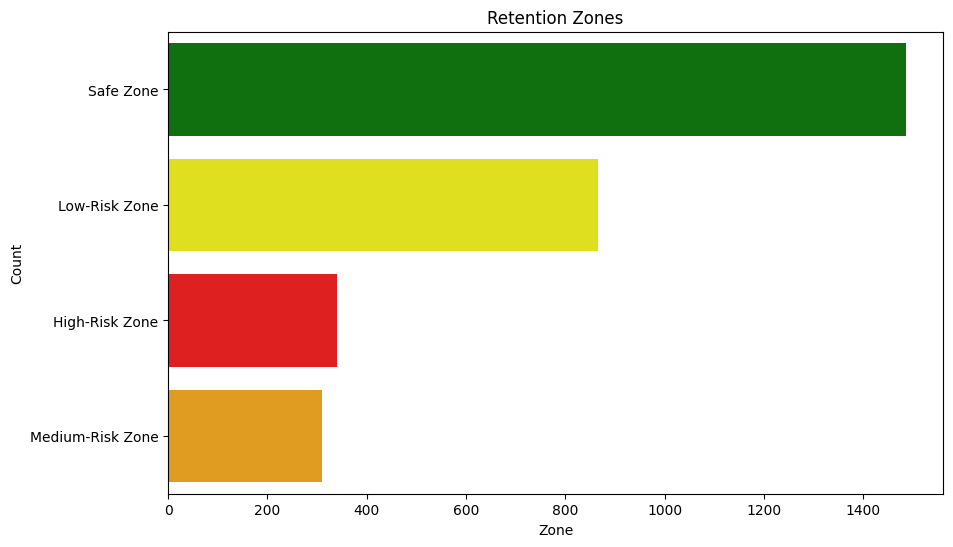

In [133]:
# create countplot of zone and color
plt.figure(figsize=(10,6))
sns.countplot(data=df,y='zone',palette=color)
plt.title('Retention Zones')
plt.xlabel('Zone')
plt.ylabel('Count')
plt.show()
